In [34]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

In [35]:
df = pd.read_csv('Mall_Customers.csv')

In [36]:
# 1. Data Preprocessing
print("Original DataFrame Shape:", df.shape)

# Remove CustomerID if exists
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()

# Define features
numeric_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
categorical_features = ['Gender']

# Display basic statistics
print("\nNumeric Features Statistics:")
print(df[numeric_features].describe())

# Display categorical features distribution
print("\nCategorical Features Distribution:")
print(df[categorical_features].value_counts())

Original DataFrame Shape: (200, 5)

Missing Values:
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Number of duplicate rows: 0

Numeric Features Statistics:
              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.000000               73.000000
max     70.000000          137.000000               99.000000

Categorical Features Distribution:
Gender
Female    112
Male       88
Name: count, dtype: int64


In [37]:
# 2. Feature Engineering and Scaling

# Create preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first'))
])

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Fit and transform the data
X = df[numeric_features + categorical_features]
X_scaled = preprocessor.fit_transform(X)

# Get feature names after transformation
numeric_features_new = numeric_features
categorical_features_new = [f'Gender_{cat}' for cat in preprocessor.named_transformers_['cat'].named_steps['onehot'].categories_[0][1:]]
feature_names = numeric_features_new + categorical_features_new

print("Scaled features shape:", X_scaled.shape)
print("Feature names:", feature_names)

Scaled features shape: (200, 4)
Feature names: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Male']


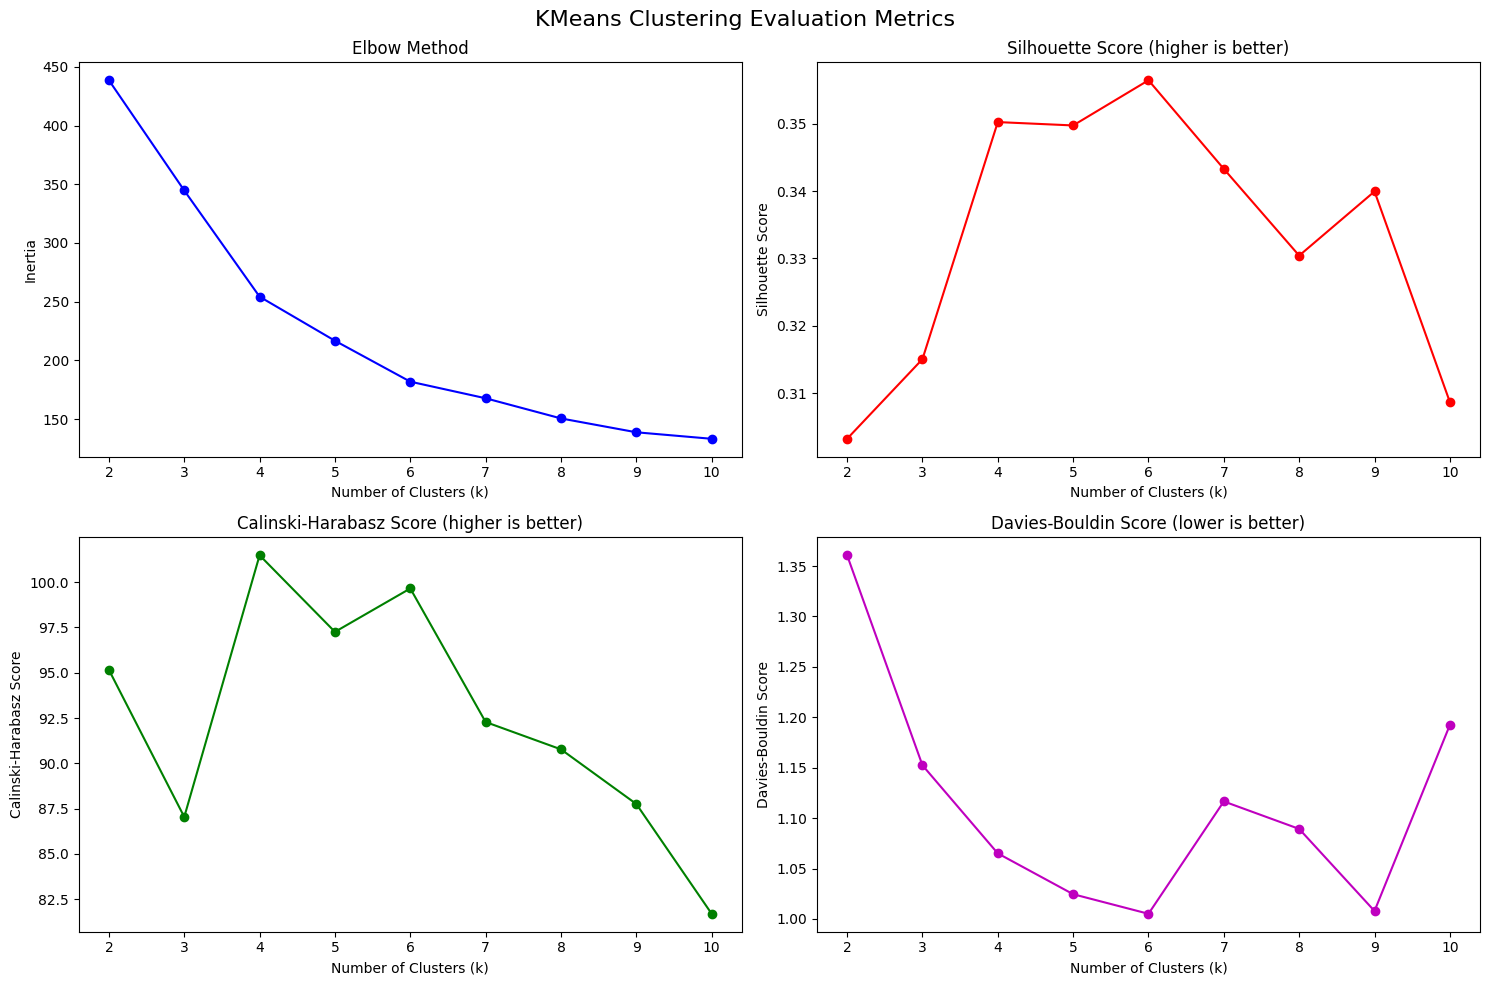

Best k according to:
Silhouette Score: 6
Calinski-Harabasz Score: 4
Davies-Bouldin Score: 6

Selected optimal k = 6


In [38]:
# 3. Find Optimal K using multiple metrics

def evaluate_kmeans(X, k_range):
    inertias = []
    silhouette_scores = []
    calinski_scores = []
    davies_scores = []
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        inertias.append(kmeans.inertia_)
        
        if k > 1:  # Silhouette score requires at least 2 clusters
            silhouette_scores.append(silhouette_score(X, labels))
            calinski_scores.append(calinski_harabasz_score(X, labels))
            davies_scores.append(davies_bouldin_score(X, labels))
        
    return inertias, silhouette_scores, calinski_scores, davies_scores

# Evaluate for k=2 to 10
k_range = range(2, 11)
inertias, silhouette_scores, calinski_scores, davies_scores = evaluate_kmeans(X_scaled, k_range)

# Plot all metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('KMeans Clustering Evaluation Metrics', fontsize=16)

# Elbow plot
axes[0, 0].plot(list(k_range), inertias, 'bo-')
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Elbow Method')

# Silhouette score
axes[0, 1].plot(list(k_range), silhouette_scores, 'ro-')
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_title('Silhouette Score (higher is better)')

# Calinski-Harabasz score
axes[1, 0].plot(list(k_range), calinski_scores, 'go-')
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Calinski-Harabasz Score')
axes[1, 0].set_title('Calinski-Harabasz Score (higher is better)')

# Davies-Bouldin score
axes[1, 1].plot(list(k_range), davies_scores, 'mo-')
axes[1, 1].set_xlabel('Number of Clusters (k)')
axes[1, 1].set_ylabel('Davies-Bouldin Score')
axes[1, 1].set_title('Davies-Bouldin Score (lower is better)')

plt.tight_layout()
plt.show()

# Find best k using multiple metrics
best_k_silhouette = k_range[np.argmax(silhouette_scores)]
best_k_calinski = k_range[np.argmax(calinski_scores)]
best_k_davies = k_range[np.argmin(davies_scores)]

print(f"Best k according to:")
print(f"Silhouette Score: {best_k_silhouette}")
print(f"Calinski-Harabasz Score: {best_k_calinski}")
print(f"Davies-Bouldin Score: {best_k_davies}")

# Choose final k (use silhouette score as primary metric)
optimal_k = best_k_silhouette
print(f"\nSelected optimal k = {optimal_k}")

In [39]:
# 4. Train Final Model with Optimal K

# Create and fit final pipeline
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('kmeans', KMeans(n_clusters=optimal_k, random_state=42, n_init=10))
])

# Fit pipeline and get cluster labels
final_pipeline.fit(X)
df['Cluster'] = final_pipeline.named_steps['kmeans'].labels_

# Get cluster centers and transform back to original scale
cluster_centers = final_pipeline.named_steps['kmeans'].cluster_centers_

# Create meaningful cluster labels based on characteristics
def get_cluster_characteristics(centers, feature_names):
    cluster_labels = {}
    for i, center in enumerate(centers):
        # Get the dominant characteristics
        income_level = center[1]  # Annual Income index
        spending_level = center[2]  # Spending Score index
        
        if income_level > 0.5 and spending_level > 0.5:
            label = "Affluent Enthusiasts"
        elif income_level > 0.5 and spending_level < -0.5:
            label = "Conservative High-Earners"
        elif income_level < -0.5 and spending_level > 0.5:
            label = "Budget Shoppers"
        elif income_level < -0.5 and spending_level < -0.5:
            label = "Value-Conscious"
        else:
            label = "Average Consumers"
            
        cluster_labels[i] = label
    return cluster_labels

cluster_labels = get_cluster_characteristics(cluster_centers, feature_names)
df['Segment'] = df['Cluster'].map(cluster_labels)

# Print cluster sizes
print("Cluster Sizes:")
print(df['Segment'].value_counts())

Cluster Sizes:
Segment
Average Consumers            83
Affluent Enthusiasts         39
Conservative High-Earners    34
Budget Shoppers              23
Value-Conscious              21
Name: count, dtype: int64


Clustering Quality Metrics:
Silhouette Score: 0.356
Calinski-Harabasz Score: 99.655
Davies-Bouldin Score: 1.005

Cluster Characteristics:
                             Age        Annual Income (k$)         \
                            mean    std               mean    std   
Segment                                                             
Affluent Enthusiasts       32.69   3.73              86.54  16.31   
Average Consumers          42.90  16.64              55.36   9.43   
Budget Shoppers            25.00   5.30              25.26   7.72   
Conservative High-Earners  41.26  10.77              88.50  16.53   
Value-Conscious            45.52  11.77              26.29   7.44   

                          Spending Score (1-100)         
                                            mean    std  
Segment                                                  
Affluent Enthusiasts                       82.13   9.36  
Average Consumers                          49.10   7.01  
Budget Shoppers    

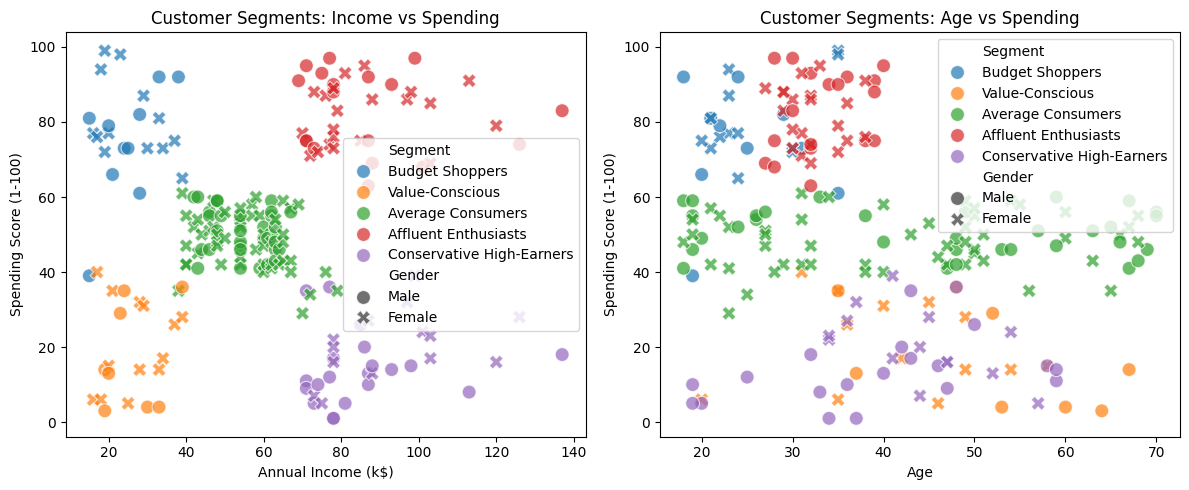


Segment Profiles:

Budget Shoppers:
Count: 23 customers
Average characteristics:
Age                       25.00
Annual Income (k$)        25.26
Spending Score (1-100)    77.61
dtype: float64
Gender distribution:
Gender
Female    0.57
Male      0.43
Name: proportion, dtype: float64

Value-Conscious:
Count: 21 customers
Average characteristics:
Age                       45.52
Annual Income (k$)        26.29
Spending Score (1-100)    19.38
dtype: float64
Gender distribution:
Gender
Female    0.62
Male      0.38
Name: proportion, dtype: float64

Average Consumers:
Count: 83 customers
Average characteristics:
Age                       42.90
Annual Income (k$)        55.36
Spending Score (1-100)    49.10
dtype: float64
Gender distribution:
Gender
Female    0.61
Male      0.39
Name: proportion, dtype: float64

Affluent Enthusiasts:
Count: 39 customers
Average characteristics:
Age                       32.69
Annual Income (k$)        86.54
Spending Score (1-100)    82.13
dtype: float64
Gende

In [40]:
# 5. Model Evaluation and Visualization

# Calculate clustering metrics
final_silhouette = silhouette_score(X_scaled, df['Cluster'])
final_calinski = calinski_harabasz_score(X_scaled, df['Cluster'])
final_davies = davies_bouldin_score(X_scaled, df['Cluster'])

print("Clustering Quality Metrics:")
print(f"Silhouette Score: {final_silhouette:.3f}")
print(f"Calinski-Harabasz Score: {final_calinski:.3f}")
print(f"Davies-Bouldin Score: {final_davies:.3f}")

# Analyze cluster characteristics
print("\nCluster Characteristics:")
numeric_summary = df.groupby('Segment')[numeric_features].agg(['mean', 'std']).round(2)
print(numeric_summary)

# Visualization
plt.figure(figsize=(12, 5))

# Plot 1: Income vs Spending Score
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Segment', style='Gender', s=100, alpha=0.7)
plt.title('Customer Segments: Income vs Spending')

# Plot 2: Age vs Spending Score
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)', 
                hue='Segment', style='Gender', s=100, alpha=0.7)
plt.title('Customer Segments: Age vs Spending')

plt.tight_layout()
plt.show()

# Additional insights
print("\nSegment Profiles:")
for segment in df['Segment'].unique():
    segment_data = df[df['Segment'] == segment]
    print(f"\n{segment}:")
    print(f"Count: {len(segment_data)} customers")
    print("Average characteristics:")
    print(segment_data[numeric_features].mean().round(2))
    print(f"Gender distribution:")
    print(segment_data['Gender'].value_counts(normalize=True).round(2))

In [41]:
# 6. Save the Model and Results

# 1. Save the complete pipeline (preprocessor + kmeans)
import joblib
import os

# Create a 'models' directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

# Save the pipeline
pipeline_filename = 'models/customer_segmentation_pipeline.joblib'
joblib.dump(final_pipeline, pipeline_filename)

# Save the cluster labels mapping
labels_filename = 'models/cluster_labels_mapping.joblib'
joblib.dump(cluster_labels, labels_filename)

# Save the feature names
features_filename = 'models/feature_names.joblib'
joblib.dump({'numeric_features': numeric_features, 
            'categorical_features': categorical_features}, 
            features_filename)

print("Model and mappings saved successfully!")
print(f"Pipeline saved to: {pipeline_filename}")
print(f"Cluster labels mapping saved to: {labels_filename}")
print(f"Feature names saved to: {features_filename}")



Model and mappings saved successfully!
Pipeline saved to: models/customer_segmentation_pipeline.joblib
Cluster labels mapping saved to: models/cluster_labels_mapping.joblib
Feature names saved to: models/feature_names.joblib
